# The analysis explores customer churn patterns, focusing on various factors such as payment methods, contract types, tenure, and demographic attributes. 
## *The goal is to identify which factors are most strongly associated with higher churn rates to guide customer retention strategies.*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Customer Churn.csv")

In [7]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Inspection of Data

In [9]:
df.shape

(7043, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## *Replacing blanks with 0 as tenure is 0 and no total charges are recorded also converting the datatype of TotalCharges from object to float.*

In [14]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Cleaning Data

In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [22]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [24]:
df.duplicated().sum()

np.int64(0)

In [26]:
df["customerID"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: customerID, Length: 7043, dtype: bool

## *We can do Conversion of data 0 and 1 values of Senior Cititzen to yes/no to make it easier to understand.*

### def conv(value): if value == 1: return "yes" else: return "no" df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

# Analyzing the Data

## *Count of customers who have churned out or not?*

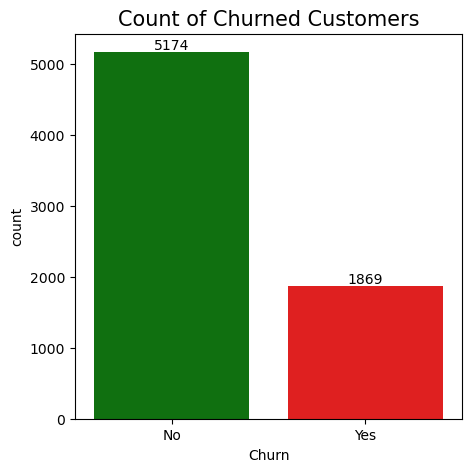

In [217]:
plt.figure(figsize = (5,5))
ax = sns.countplot(x = "Churn", data = df, hue = "Churn", palette = {"No": "green", "Yes": "red"}, legend = False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Churned Customers", fontsize = 15)
plt.show()

## *Percentage of customers who have churned out or not*

In [161]:
gb = df.groupby("Churn").agg({'Churn':'count'})


In [163]:
gb

,Churn
Churn,
No,5174
Yes,1869


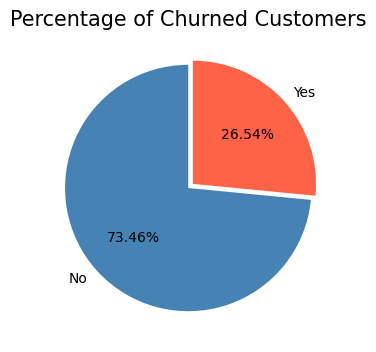

In [201]:
plt.figure(figsize=(4,4))
plt.pie(gb["Churn"], labels=gb.index, autopct="%1.2f%%", 
        colors=["steelblue", "tomato"], startangle=90, explode=[0, 0.05])
plt.title("Percentage of Churned Customers", fontsize=15)
plt.show()

## *From the given pie chart we can conclude that 26.54% of our Customers have Churned out.*
## *Now let's Explore the reason behind it...*

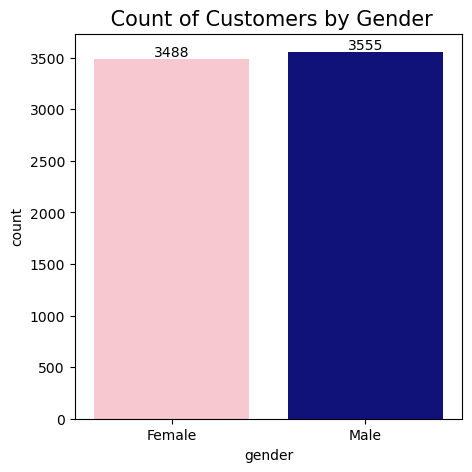

In [225]:
plt.figure(figsize = (5,5))
gen = sns.countplot(x = "gender", data = df, hue = "gender", palette = {"Male": "darkblue", "Female": "pink"}, legend = False)
for container in gen.containers:
    gen.bar_label(container)
plt.title(" Count of Customers by Gender", fontsize = 15)
plt.show()


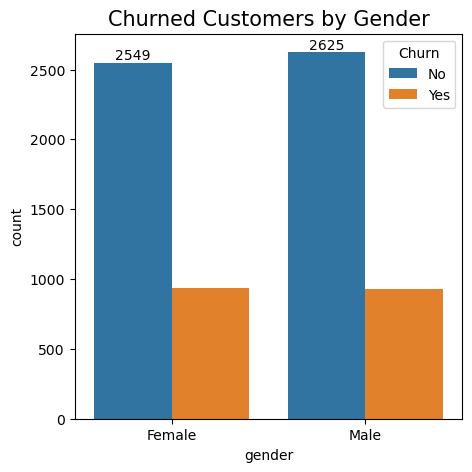

In [363]:
plt.figure(figsize = (5,5))
gen = sns.countplot(x = "gender", data = df, hue = "Churn")
gen.bar_label(gen.containers[0])
plt.title("Churned Customers by Gender", fontsize = 15)
plt.show()

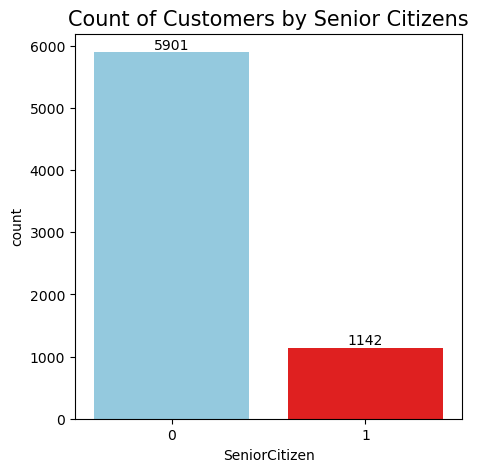

In [221]:
plt.figure(figsize = (5,5))
sc = sns.countplot(x = "SeniorCitizen", data = df, hue = "SeniorCitizen", palette = {0 : "skyblue", 1 : "red"}, legend = False)
for container in sc.containers:
    sc.bar_label(container)
plt.title("Count of Customers by Senior Citizens", fontsize = 15)
plt.show()
#0 = NO AND 1 = YES

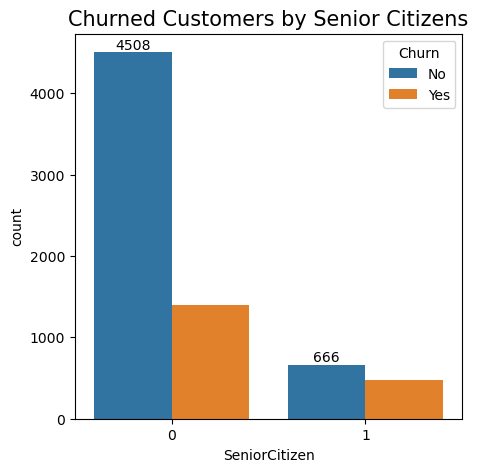

In [229]:
plt.figure(figsize = (5,5))
sc = sns.countplot(x = "SeniorCitizen", data = df, hue = "Churn")
sc.bar_label(sc.containers[0])
plt.title("Churned Customers by Senior Citizens", fontsize = 15)
plt.show()

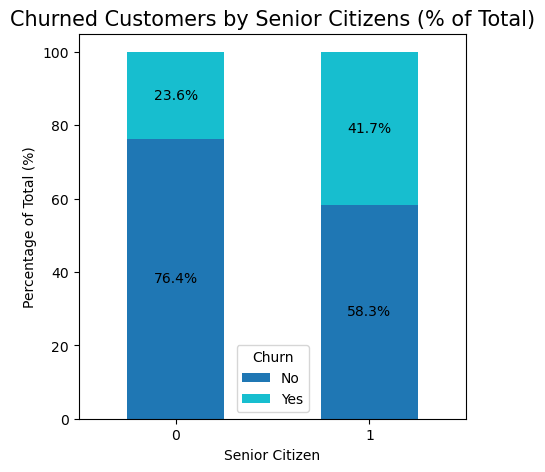

In [142]:
# Get counts and convert to % of total
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar
ax1 = ct_pct.plot(kind="bar", stacked=True, figsize=(5,5), colormap="tab10")

# Add % labels
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.1f%%", label_type="center", color="Black")

plt.title("Churned Customers by Senior Citizens (% of Total)", fontsize=15)
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage of Total (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

## *Comparatively a greater percentage of people in Senior Citizen category have churned out.*

<function matplotlib.pyplot.show(close=None, block=None)>

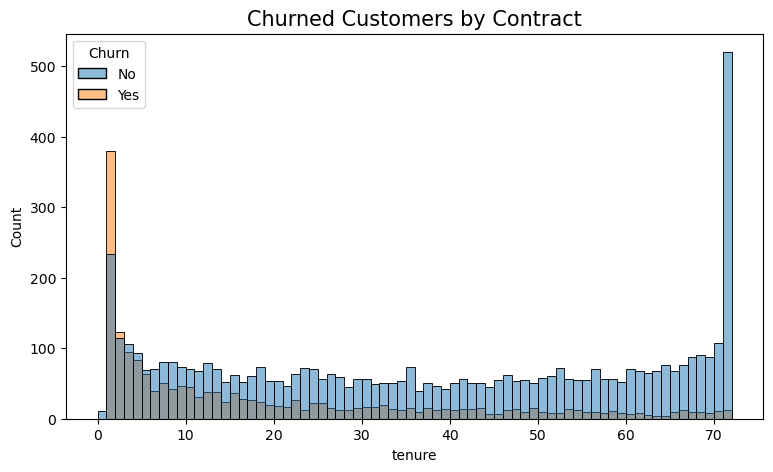

In [120]:
plt.figure(figsize = (9,5))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.title("Churned Customers by Contract", fontsize = 15)
plt.show

## *People who have used our services for a long time have stayed and people who have used our services for #1 or #2 months have churned.*

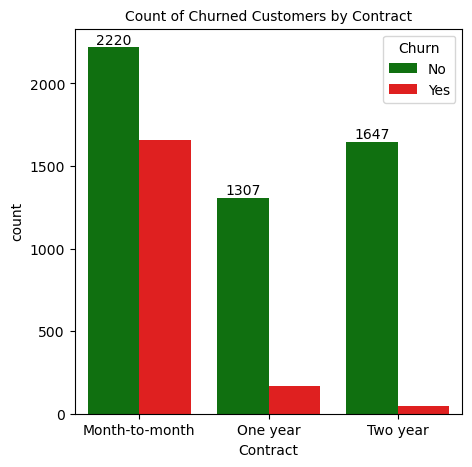

In [231]:
plt.figure(figsize = (5,5))
con = sns.countplot(x = "Contract", data = df, hue = "Churn", palette={"No": "green", "Yes": "red"})
con.bar_label(con.containers[0])
plt.title("Count of Churned Customers by Contract", fontsize = 10)
plt.show()

## *People who have month to month contract are likely to churn then from those who have 1 or 2 years of contract.*

In [92]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

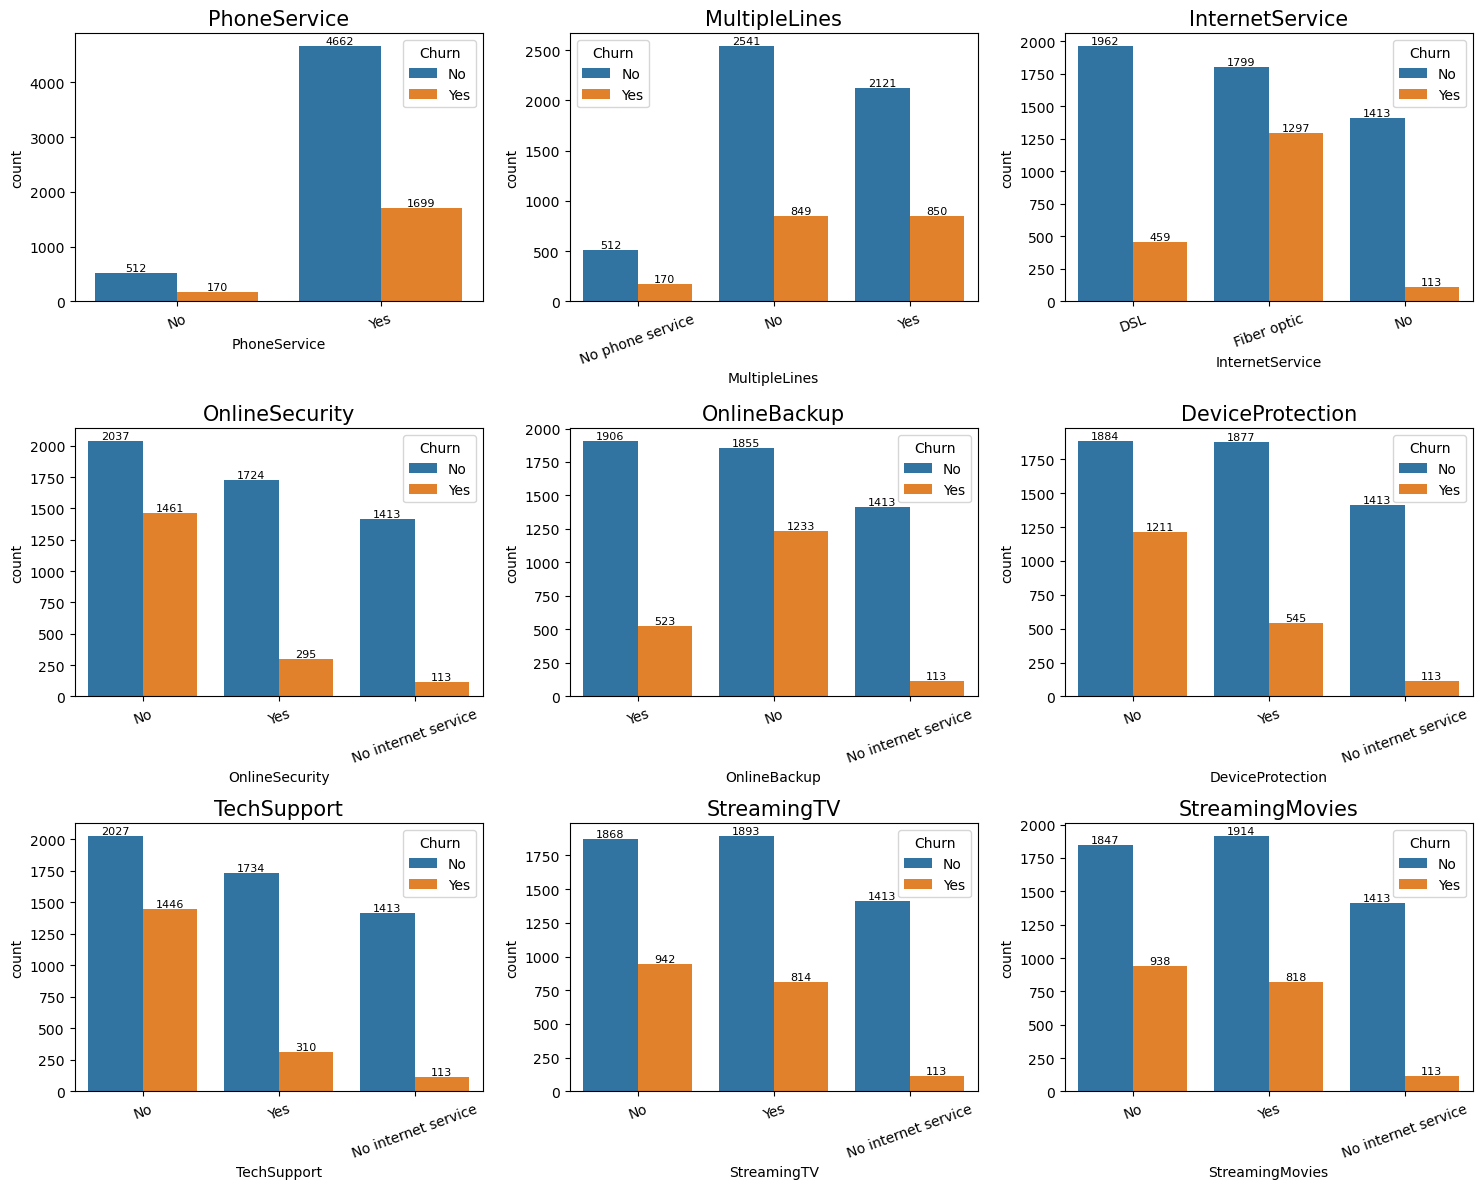

In [138]:
#Characteristics
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(x=col, data=df, hue="Churn", ax=axes[i])
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)
    ax.set_title(col, fontsize=15)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Customers without add-on services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport) show noticeably higher churn than those with them 
### e.g., churn drops sharply once "No internet service" applies, since those customers churn least overall. 
## Fiber optic internet users churn far more than DSL or no-internet users, suggesting service or pricing dissatisfaction. 
## Streaming services (TV/Movies) show a more balanced churn split, indicating they're less predictive of churn than security/support-related services.

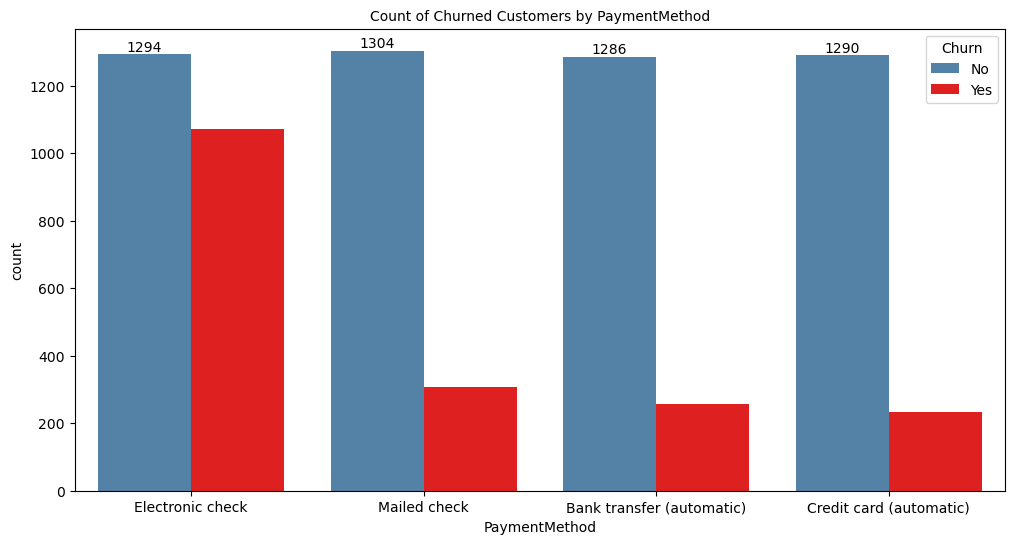

In [209]:
plt.figure(figsize = (12,6))
pm = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn", palette={"No": "steelblue", "Yes": "red"})
pm.bar_label(pm.containers[0])
plt.title("Count of Churned Customers by PaymentMethod", fontsize = 10)
plt.show()

## *Customers are likely to churn when they are using electronic check as a PaymentMethod.*

# *Conclusion*

## Overall, 26.54% of customers have churned. 
### Churn is strongly linked to a lack of engagement and commitment : 
### Customers with month-to-month contracts, short tenure (1–2 months), electronic check payments, fiber optic internet, and no add-on services (security, backup, device protection, tech support) all show substantially higher churn rates. 
### Senior citizens also churn at a higher rate than non-seniors. 
### In contrast, long-tenured customers, those with longer-term contracts, and those with support/security add-ons are far more likely to stay. 
### Demographics like gender and streaming service usage show little to no predictive power for churn.

# *Recommendations*
### 1. Incentivize longer contracts — offer discounts or perks to shift month-to-month customers toward 1- or 2-year plans, since these show the strongest retention.
### 2. Target the first 1–2 months — build an onboarding/engagement program (welcome offers, proactive check-ins) since churn is heavily concentrated in early tenure.
### 3. Promote add-on services — bundle OnlineSecurity, TechSupport, DeviceProtection, and OnlineBackup at a discount, as customers with these services churn far less.
### 4. Address fiber optic dissatisfaction — investigate pricing/service quality complaints for fiber customers, since they churn much more than DSL users.
### 5. Reduce friction around electronic check payments — encourage migration to automatic bank transfer/credit card payments, which correlate with lower churn (possibly a proxy for lower engagement or trust).
### 6. Create senior citizen-focused retention plans — tailored support or pricing for this segment, given their elevated churn rate.